In [ ]:
# download wine quality dataset directly
!wget https://archive.ics.uci.edu/static/public/186/wine+quality.zip

--2023-07-26 20:09:58--  https://archive.ics.uci.edu/static/public/186/wine+quality.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘wine+quality.zip’

wine+quality.zip        [ <=>                ]  89.21K  --.-KB/s    in 0.1s    

2023-07-26 20:09:59 (890 KB/s) - ‘wine+quality.zip’ saved [91353]



In [ ]:
# unzip the wine quality dataset
!unzip wine+quality.zip

Archive:  wine+quality.zip
  inflating: winequality-red.csv     
  inflating: winequality-white.csv   
  inflating: winequality.names       


In [ ]:
# open up the files
opened_red_data = open('/content/winequality-red.csv','r')
opened_white_data = open('/content/winequality-white.csv','r')

# read the data and remove the names
red_data_lines = opened_red_data.readlines()
opened_red_data.close()
red_data_lines.pop(0)

# do the same for the white wines
white_data_lines = opened_white_data.readlines()
opened_white_data.close()
white_data_lines.pop(0)


'"fixed acidity";"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"\n'

In [ ]:
# here we make cleaned_red_data to eventually put all of our data
cleaned_red_data = []

for line in red_data_lines:
  # the data is separated by semicolons, so we split by those
  split_line = line.split(';')

  # for each of the features, we convert it into numbers
  for i in range(12):
    split_line[i] = float(split_line[i])

  # here, we add 0 for the class
  # 0 is for red wine
  split_line.append(0)

  # we add the line to cleaned_red_data
  cleaned_red_data.append(split_line)

In [ ]:
# we do the same for white data
cleaned_white_data = []

for line in white_data_lines:
  split_line = line.split(';')

  for i in range(12):
    split_line[i] = float(split_line[i])

  # 1 is for white wine
  split_line.append(1)

  cleaned_white_data.append(split_line)

In [ ]:
# import pandas under the nickname of pd
import pandas as pd

# add the lists together and join them into a dataframe
all_data = cleaned_red_data + cleaned_white_data
data = pd.DataFrame(all_data)
data

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5.0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5.0,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5.0,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6.0,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6.0,1
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5.0,1
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6.0,1
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7.0,1


In [ ]:
# shuffle the data, using a random state of 0
data = data.sample(frac=1,random_state=0)
# here, we reset the indices to be in order and we don't want to get
# the old indices as a new column, so drop = True
data = data.reset_index(drop=True)
data.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,6.3,0.18,0.24,3.40,0.053,20.0,119.0,0.99373,3.11,0.52,9.2,6.0,1
1,6.8,0.14,0.18,1.40,0.047,30.0,90.0,0.99164,3.27,0.54,11.2,6.0,1
2,7.3,0.22,0.50,13.70,0.049,56.0,189.0,0.99940,3.24,0.66,9.0,6.0,1
3,7.6,0.67,0.14,1.50,0.074,25.0,168.0,0.99370,3.05,0.51,9.3,5.0,1
4,7.3,0.21,0.29,1.60,0.034,29.0,118.0,0.99170,3.30,0.50,11.0,8.0,1
5,7.0,0.12,0.19,4.90,0.055,27.0,127.0,0.99530,3.29,0.41,9.4,5.0,1
6,6.8,0.16,0.18,1.80,0.046,31.0,114.0,0.99226,3.27,0.55,10.8,6.0,1
7,6.9,0.38,0.29,13.65,0.048,52.0,189.0,0.99784,3.00,0.60,9.5,6.0,1
8,8.8,0.45,0.43,1.40,0.076,12.0,21.0,0.99551,3.21,0.75,10.2,6.0,0
9,6.3,0.20,0.26,12.70,0.046,60.0,143.0,0.99526,3.26,0.35,10.8,6.0,1


In [ ]:
x = data.iloc[:, 0:12]
x

,0,1,2,3,4,5,6,7,8,9,10,11
0,5.8,0.555,0.26,4.5,0.053,17.0,126.0,0.99430,3.24,0.46,9.1,5.0
1,6.5,0.130,0.37,1.0,0.036,48.0,114.0,0.99110,3.41,0.51,11.5,8.0
2,5.9,0.250,0.19,12.4,0.047,50.0,162.0,0.99730,3.35,0.38,9.5,5.0
3,6.4,0.390,0.21,1.2,0.041,35.0,136.0,0.99225,3.15,0.46,10.2,5.0
4,7.2,0.250,0.28,14.4,0.055,55.0,205.0,0.99860,3.12,0.38,9.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4993,5.8,0.380,0.26,1.1,0.058,20.0,140.0,0.99271,3.27,0.43,9.7,6.0
4994,7.8,0.300,0.36,4.6,0.024,20.0,198.0,0.99222,3.06,0.66,11.9,6.0
4995,6.9,0.300,0.49,7.6,0.057,25.0,156.0,0.99620,3.43,0.63,11.0,7.0
4996,7.1,0.340,0.31,5.2,0.032,36.0,140.0,0.99166,3.35,0.47,12.3,7.0


In [ ]:
y = data[12]
y

0       1
1       1
2       1
3       1
4       1
       ..
4993    1
4994    1
4995    1
4996    1
4997    1
Name: 12, Length: 4998, dtype: int64

In [ ]:
# training is separated into
train_x = x[:-200]
train_y = y[:-200]
test_x = x[-200:]
test_y = y[-200:]

In [ ]:
# import and fit the decision tree
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier()
clf = clf.fit(train_x,train_y)

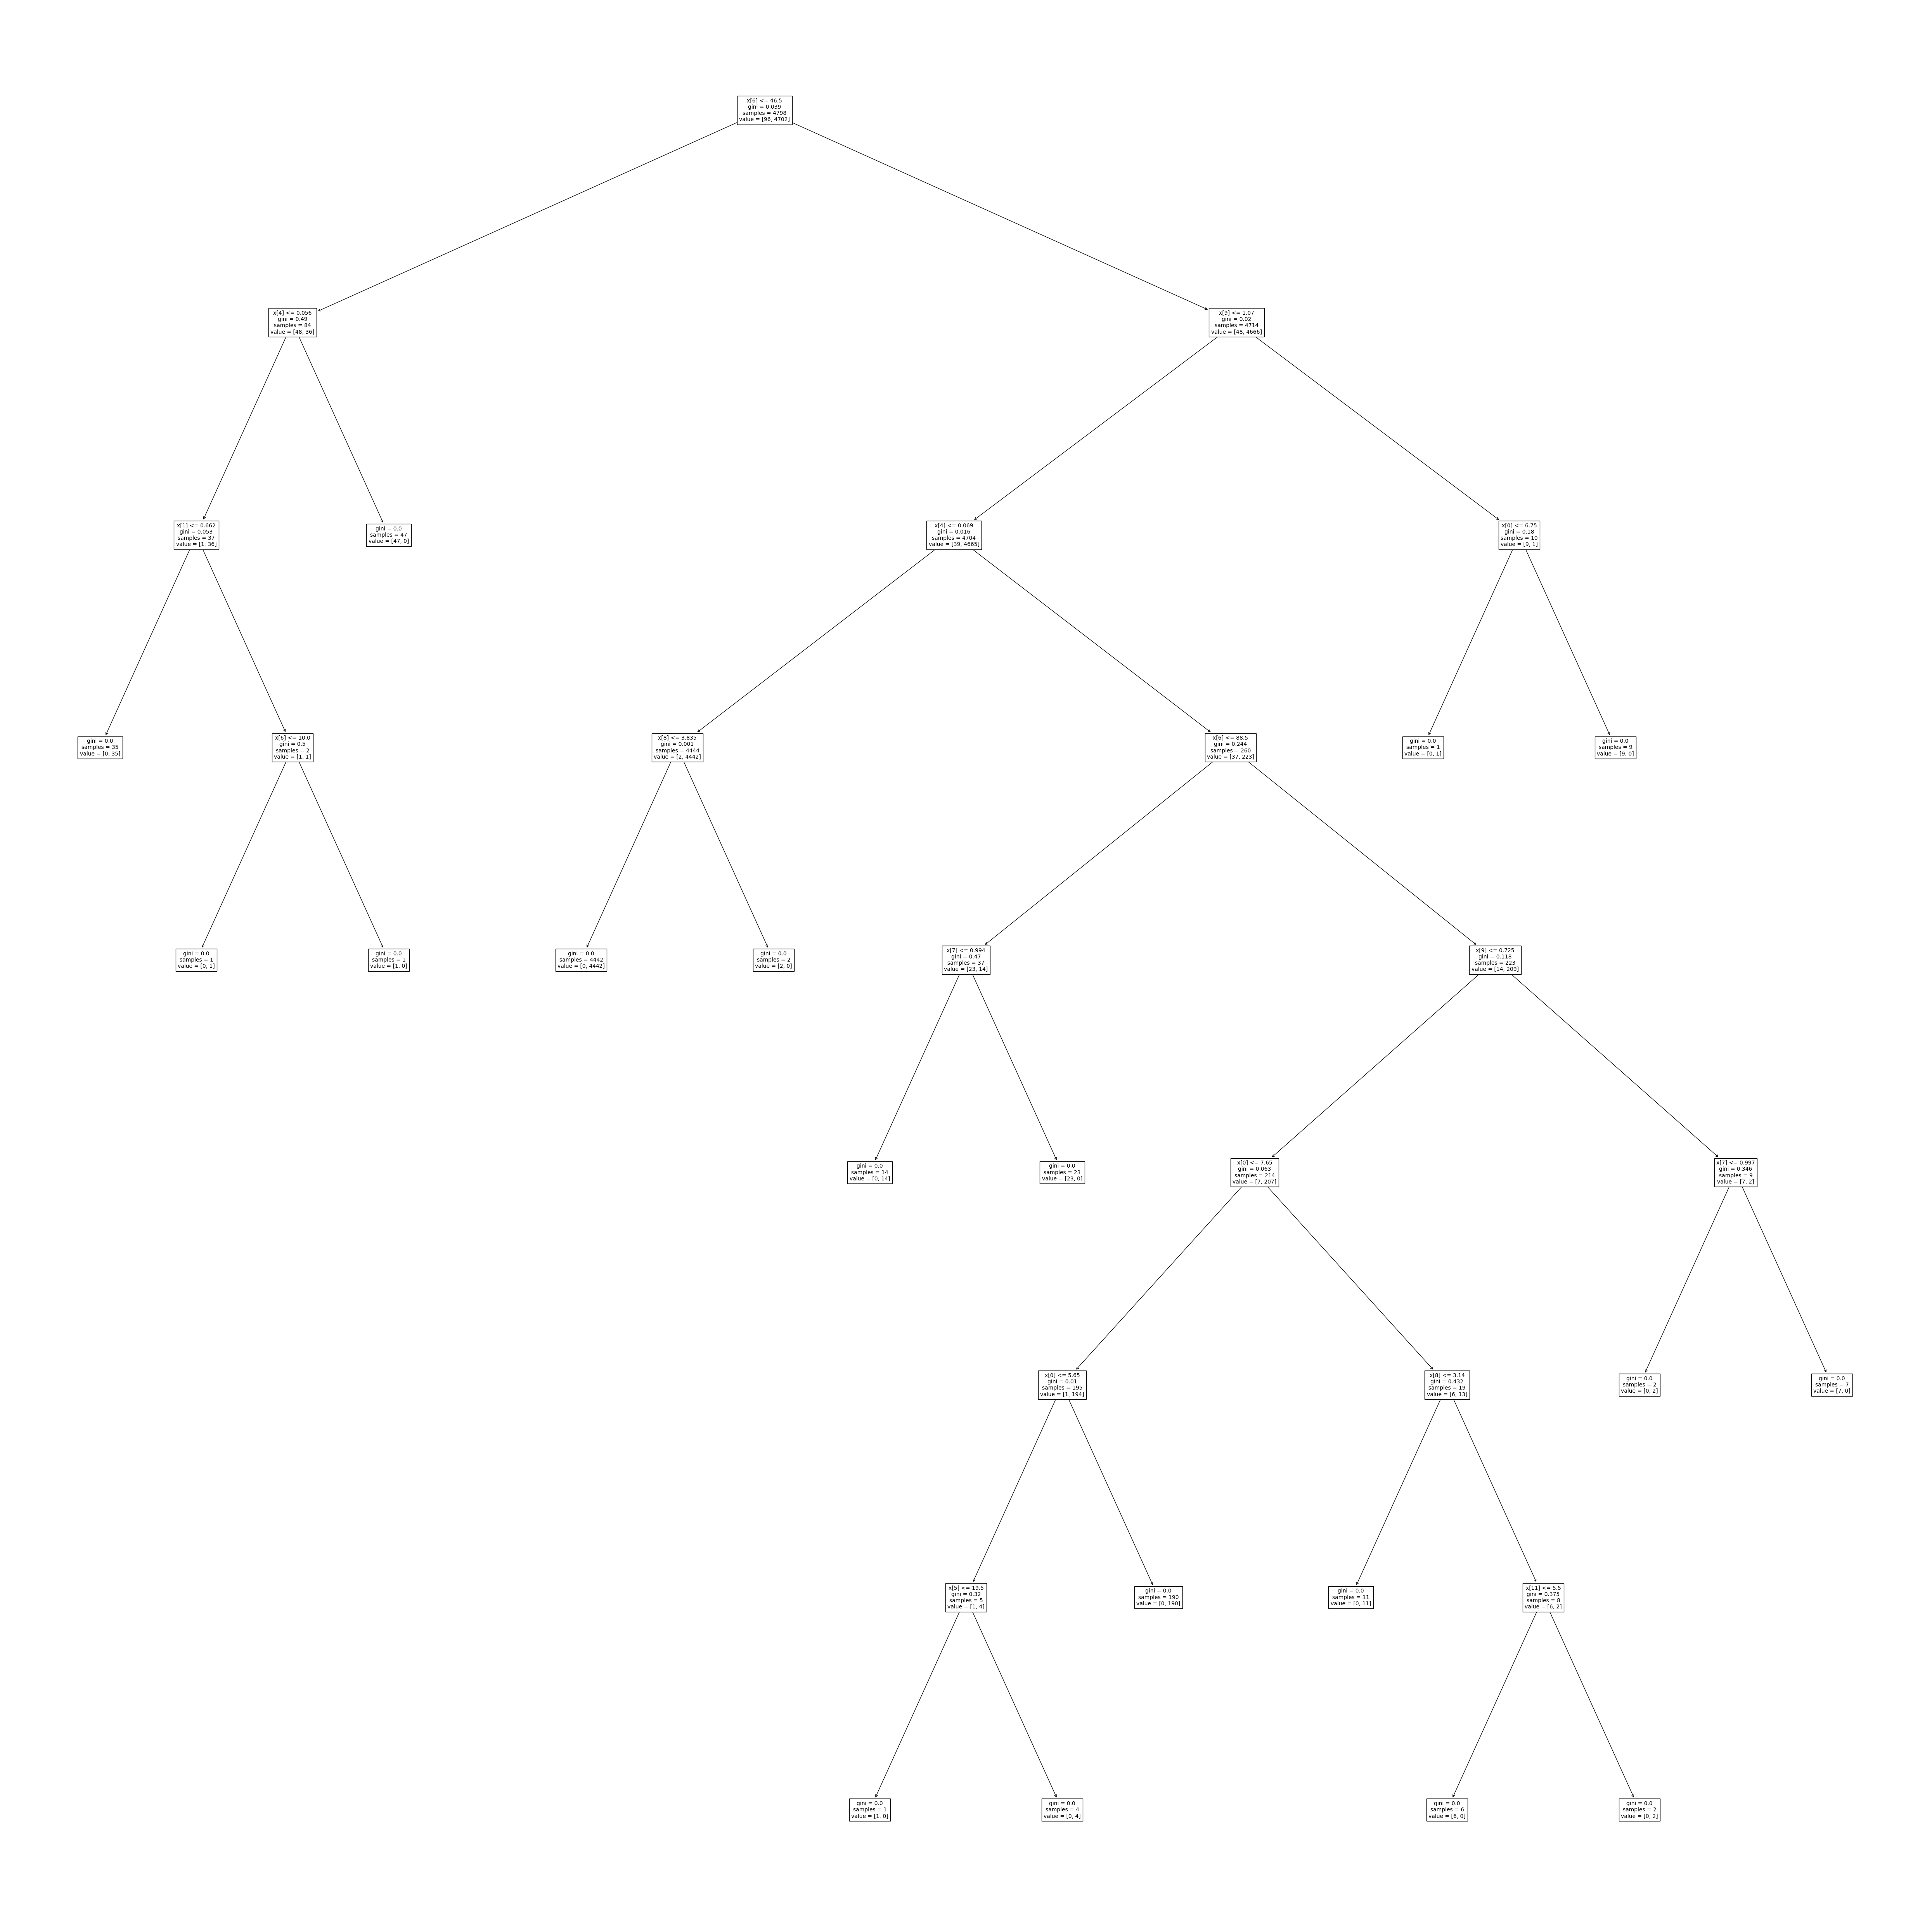

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# current image is too low resolution make decision tree higher resolution,
# stackoverflow is a very helpful tool to figure out problems like this
plt.figure(figsize=(64, 64))  # set plot size (denoted in inches)
plot_tree(clf, fontsize=10)
# We call the tree plot tool, which puts it on the matplotlib graph
# plot_tree(clf)
# And we save the figure
plt.savefig("tree.png")

# zoom in!

In [ ]:
# import random forest
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

# fit on the training data
clf = clf.fit(train_x, train_y)

In [ ]:
# score testing data
clf.score(test_x, test_y)

0.995

In [ ]:
# import svm
from sklearn import svm

# fit on the training data
clf = svm.SVC()
clf.fit(train_x,train_y)

SVC()

In [ ]:
# score the testing data
clf.score(test_x,test_y)

0.945

In [ ]:
from sklearn.naive_bayes import GaussianNB

# naive bayes requires everything in float form; won't accept strings

# fit on the training data
clf = GaussianNB()
clf = clf.fit(train_x,train_y)

In [ ]:
# score on the testing data
clf.score(test_x,test_y)

0.97

### Bonus Task:

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# import and fit with 10 neighbors
clf = KNeighborsClassifier(n_neighbors = 10)
clf = clf.fit(train_x, train_y)

In [ ]:
clf.score(test_x, test_y)

0.94

In [ ]:
# make data unbalanced
unbalanced_data = cleaned_red_data[:100] + cleaned_white_data
data = pd.DataFrame(unbalanced_data)
data

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5.0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5.0,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5.0,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6.0,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6.0,1
4994,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5.0,1
4995,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6.0,1
4996,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7.0,1


In [ ]:
# shuffle
data = data.sample(frac=1,random_state=0)
data = data.reset_index(drop=True)
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,5.8,0.555,0.26,4.5,0.053,17.0,126.0,0.99430,3.24,0.46,9.1,5.0,1
1,6.5,0.130,0.37,1.0,0.036,48.0,114.0,0.99110,3.41,0.51,11.5,8.0,1
2,5.9,0.250,0.19,12.4,0.047,50.0,162.0,0.99730,3.35,0.38,9.5,5.0,1
3,6.4,0.390,0.21,1.2,0.041,35.0,136.0,0.99225,3.15,0.46,10.2,5.0,1
4,7.2,0.250,0.28,14.4,0.055,55.0,205.0,0.99860,3.12,0.38,9.0,7.0,1


In [ ]:
# same processing as earlier
x = pd.DataFrame()

# take first 12 features as input feature
for i in range(12):
  x[i] = data[i]
y = data[12]

In [ ]:
train_x = x[:-200]
train_y = y[:-200]
test_x = x[-200:]
test_y = y[-200:]

In [ ]:
# make a "model" to predict 1 the whole time
y_pred = [1 for i in range(200)]

In [ ]:
clf.score(test_x,y_pred)

0.975

In [ ]:
x = pd.DataFrame()

# take first 12 features as input feature
for i in range(11):
  x[i] = data[i]
x[11] = data[12]
y = data[11]

In [ ]:
train_x = x[:-200]
train_y = y[:-200]
test_x = x[-200:]
test_y = y[-200:]

In [ ]:
from sklearn.tree import DecisionTreeRegressor
reg = DecisionTreeRegressor()
reg.fit(train_x, train_y)
reg.score(test_x, test_y)

0.42902296653156935

In [ ]:
# not great, but nothing else really did well at quality either